In [215]:
import numpy as np
import pandas as pd

In [216]:
df = pd.read_csv("/run/media/darshchouhan/New Volume/ML-Algorithm/sms_spam/archive (1)/spam.csv",encoding="latin-1")

In [217]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [218]:
df.info ()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 679.7 KB


In [219]:
df['v1']

0        ham
1        ham
2       spam
3        ham
4        ham
        ... 
5567    spam
5568     ham
5569     ham
5570     ham
5571     ham
Name: v1, Length: 5572, dtype: str

In [220]:
from sklearn.preprocessing import LabelEncoder
lr = LabelEncoder()
out  = lr.fit_transform(df['v1'])

In [221]:
print(out)

[0 0 1 ... 0 0 0]


In [222]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will ï¿½_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [223]:
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [224]:
columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4']
df=df.drop(columns,axis=1)

In [225]:
df.isna().sum()

v1    0
v2    0
dtype: int64

In [226]:
df=df.rename(columns={'v1':'Target','v2':'Message'})

In [227]:
df

,Target,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ï¿½_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [228]:
df['Target']=out

In [229]:
df

,Target,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ï¿½_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [230]:
out=df.duplicated()
print(out)
count = out.count()


0       False
1       False
2       False
3       False
4       False
        ...  
5567    False
5568    False
5569    False
5570    False
5571    False
Length: 5572, dtype: bool


In [231]:
df.head(5)

,Target,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [232]:
df=df.drop_duplicates()

In [233]:
df.head(5)

,Target,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [234]:
X = df["Target"]
y = df['Message']

In [235]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25)

In [236]:
df['Target'].value_counts()

Target
0    4516
1     654
Name: count, dtype: int64

In [237]:
! pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [238]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/darshchouhan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [239]:
df['num_chara'] = df['Message'].apply(len)

In [240]:
df['Message_length']=df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [241]:
df

,Target,Message,num_chara,Message_length
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,162,35
5568,0,Will ï¿½_ b going to esplanade fr home?,39,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [242]:
df['sentence_len'] = df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [243]:
df

,Target,Message,num_chara,Message_length,sentence_len
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,162,35,4
5568,0,Will ï¿½_ b going to esplanade fr home?,39,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [244]:
# ham
df[df['Target']==0][["num_chara","Message_length","sentence_len"]].describe()

,num_chara,Message_length,sentence_len
count,4516.000000,4516.000000,4516.000000
mean,70.682905,17.123782,1.820195
std,56.435763,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [245]:
# ham
df[df['Target']==1][["num_chara","Message_length","sentence_len"]].describe()

,num_chara,Message_length,sentence_len
count,654.000000,654.000000,654.000000
mean,138.376147,27.677370,2.970948
std,30.248371,7.007426,1.487286
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,158.000000,32.000000,4.000000
max,225.000000,46.000000,9.000000


In [246]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='num_chara', ylabel='Count'>

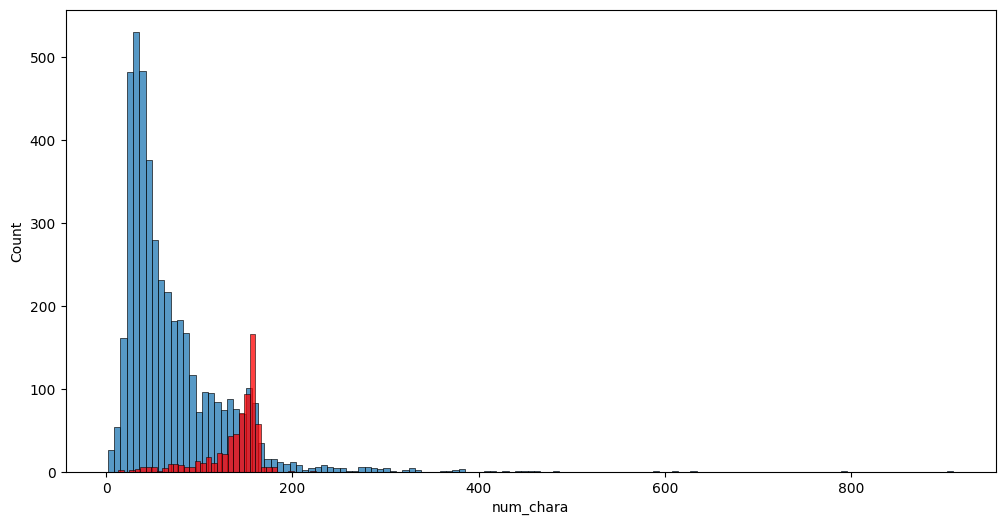

In [247]:
plt.figure(figsize=(12,6))

sns.histplot(df[df['Target']==0]["num_chara"])
sns.histplot(df[df['Target']==1]["num_chara"],color='red')

In [248]:
df.info()

<class 'pandas.DataFrame'>
Index: 5170 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Target          5170 non-null   int64
 1   Message         5170 non-null   str  
 2   num_chara       5170 non-null   int64
 3   Message_length  5170 non-null   int64
 4   sentence_len    5170 non-null   int64
dtypes: int64(4), str(1)
memory usage: 645.4 KB


<Axes: >

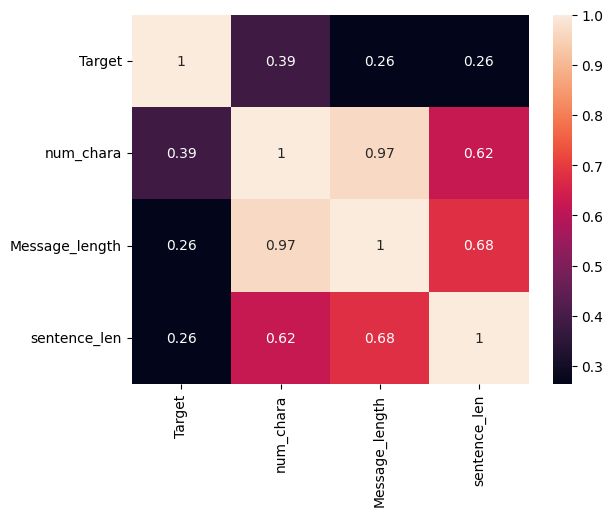

In [249]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Preprocessing
- ### Lower Case
- ### Tokenization
- ### Removing special Characters
- ### Stemming


In [250]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    print(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
            print(i)
    return y





In [251]:
transform_text("@@@ this is Hello bfsd$sda ** 32133")

['@', '@', '@', 'this', 'is', 'hello', 'bfsd', '$', 'sda', '*', '*', '32133']
this
is
hello
bfsd
sda
32133


['this', 'is', 'hello', 'bfsd', 'sda', '32133']

In [252]:
! pip install  nltk.corpus

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement nltk.corpus (from versions: none)
ERROR: No matching distribution found for nltk.corpus


In [253]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/darshchouhan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [254]:
from nltk.corpus import stopwords
res=stopwords.words('english')
print(res)
print(len(res
          ))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [255]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [256]:
stopwords = stopwords.words('english')
print(stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [257]:
from nltk.corpus import stopwords

In [258]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('dancing')
ps.stem("ducking")

'duck'

In [259]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y
    ## List of words
    y=[]
    ## we have to remove the stop words
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)      
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return y






In [260]:
df['Message'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [261]:
transform_text("'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'")

['jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat']

In [262]:
df

,Target,Message,num_chara,Message_length,sentence_len
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,162,35,4
5568,0,Will ï¿½_ b going to esplanade fr home?,39,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [263]:
transform_text('Ml is not difficult')

['ml', 'difficult']

In [264]:
transform_text('after eating sleep all am and')

['eat', 'sleep']

In [265]:
df["transformed_message"]=df['Message'].apply(transform_text)

In [266]:
! pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [267]:
from wordcloud import WordCloud
wc = WordCloud(width=900,height = 900,background_color='white')

In [268]:
msg_spam = df[df['Target']==1]['transformed_message'].apply(lambda x:" ".join(x))

In [269]:
msg_spam

2       free entri 2 wkli comp win fa cup final tkt 21...
5       freemsg hey darl 3 week word back like fun sti...
8       winner valu network custom select receivea pri...
9       mobil 11 month u r entitl updat latest colour ...
11      six chanc win cash 100 pound txt csh11 send co...
                              ...                        
5537    want explicit sex 30 sec ring 02073162414 cost...
5540    ask 3mobil 0870 chatlin inclu free min india c...
5547    contract mobil 11 mnth latest motorola nokia e...
5566    remind o2 get pound free call credit detail gr...
5567    2nd time tri 2 contact u pound prize 2 claim e...
Name: transformed_message, Length: 654, dtype: str

In [270]:
print(type(msg_spam))

<class 'pandas.Series'>


In [271]:
msg_spam = msg_spam.str.cat(sep=" ")

In [272]:
print(msg_spam)

free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18 freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030 six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18 xxxmobilemovieclub use credit click wap link next txt messag click http england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq thank subscript rington uk mobil charg pleas confirm repli ye repli charg 07732584351 rodger burn msg tri call repli sm free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow sm ac sptv new jersey devil detroit red wi

In [273]:
wc_true=wc.generate(msg_spam)


(np.float64(-0.5), np.float64(899.5), np.float64(899.5), np.float64(-0.5))

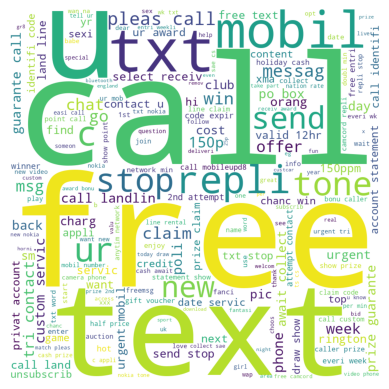

In [274]:
import matplotlib.pyplot as plt
plt.imshow(wc_true)
plt.axis('off')

In [285]:
no_spam_msg = df[df['Target']==0]['transformed_message'].apply(lambda x:" ".join(x))

In [286]:
no_spam_msg =  no_spam_msg.str.cat(sep=' ')

In [287]:
no_spam_msg = wc.generate(no_spam_msg)

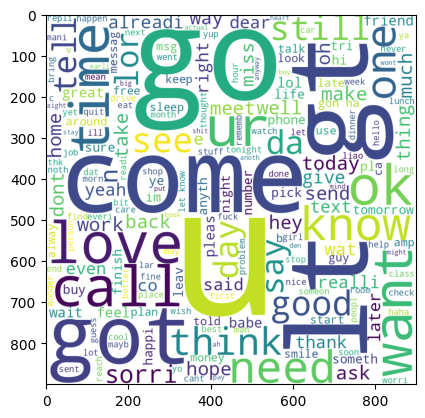

In [288]:
import matplotlib.pyplot as plt2
plt2.imshow(no_spam_msg)

## Now we will generate the  top 30-40 words

In [300]:
spam_corpus=[]
for msg in df[df['Target']==1]['transformed_message'].to_list():
    for word in msg:
        spam_corpus.append(word)

In [301]:
print(len(spam_corpus))

9954


In [310]:
spam_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

In [321]:
from collections import Counter
out=Counter(spam_corpus).most_common(30)
print(out)

[('call', 320), ('free', 191), ('2', 155), ('txt', 142), ('text', 122), ('ur', 120), ('u', 119), ('mobil', 114), ('stop', 104), ('repli', 103), ('claim', 99), ('4', 97), ('prize', 82), ('get', 74), ('new', 64), ('servic', 64), ('tone', 63), ('send', 60), ('urgent', 58), ('nokia', 57), ('award', 56), ('contact', 56), ('phone', 52), ('cash', 51), ('pleas', 51), ('week', 49), ('win', 48), ('c', 45), ('collect', 45), ('min', 45)]


In [322]:
res=pd.DataFrame(out)

In [328]:
res

,0,1
0,call,320
1,free,191
2,2,155
3,txt,142
4,text,122
5,ur,120
6,u,119
7,mobil,114
8,stop,104
9,repli,103


<Axes: xlabel='0', ylabel='1'>

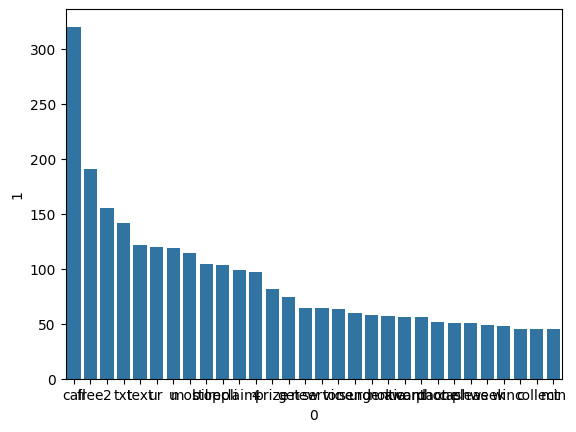

In [332]:
sns.barplot(data=res,x=0,y=1)